In [ ]:
import numpy as np
from tqdm import tqdm

from seaborn import despine
import seaborn as sns
sns.set_style("ticks")
sns.set_context("talk")

from IPython.display import Image

from matplotlib import cm
import matplotlib.pyplot as plt
%matplotlib inline

# 0. Quick overview

This notebook gives an introduction to the **Perceptron** and **Gradient Descent** algorithms.

The **Perceptron** algorithm represents the smallest building block of many modern neural network architectures. Conceptually, it is loosely inspired by the basic processing steps of biological neurons.

The **Gradient Descent** algorithm, on the other hand, provides the backbone of modern deep learning and allows you to fit the Perceptron (as well as more complex deep learning architectures) to a dataset; By finding the set of parameters that achieve the best performance in a task (e.g., deciding whether an image depicts a flower or not).

# 1. The iris dataset

In this notebook, we will be using the [Iris dataset](https://archive.ics.uci.edu/ml/datasets/iris).

This dataset contains three classes with 50 instances each; Each class refers to a type of iris plant (setosa, versicolor, and virginica). For each instance, the width and length of the petal and sepal is given (see below).

In [ ]:
url = "https://raw.githubusercontent.com/athms/deep-learning-basics/refs/heads/main/materials/images/free-use/Iris_data.png"
Image(url=url, width=1200, height=400)

*Image adapted from: https://www.pexels.com/search/iris%20flower/*

We load the data directly from the [scikit-learn](https://scikit-learn.org/stable/) library:

In [ ]:
from sklearn.datasets import load_iris
data = load_iris()

`data` is a dictionary with the following keys (or entries):

In [ ]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

The iris type is encoded in the `target` entry:

In [ ]:
data['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

The corresponding name of each iris type can be found in `target_names`:

In [ ]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

The length and width of the sepal and petal of each instance are given in the `data` entry:

In [ ]:
data['data'][:10]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

`data` contains 4 features (one per column) for each of 150 instances (one per row):

In [ ]:
data['data'].shape

(150, 4)

The corresponding name of each feature is given in `feature_names`:

In [ ]:
data['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

Let's take a closer look at the data, by plotting the data according to the sepal width and length (left) as well as the petal width and length (right):

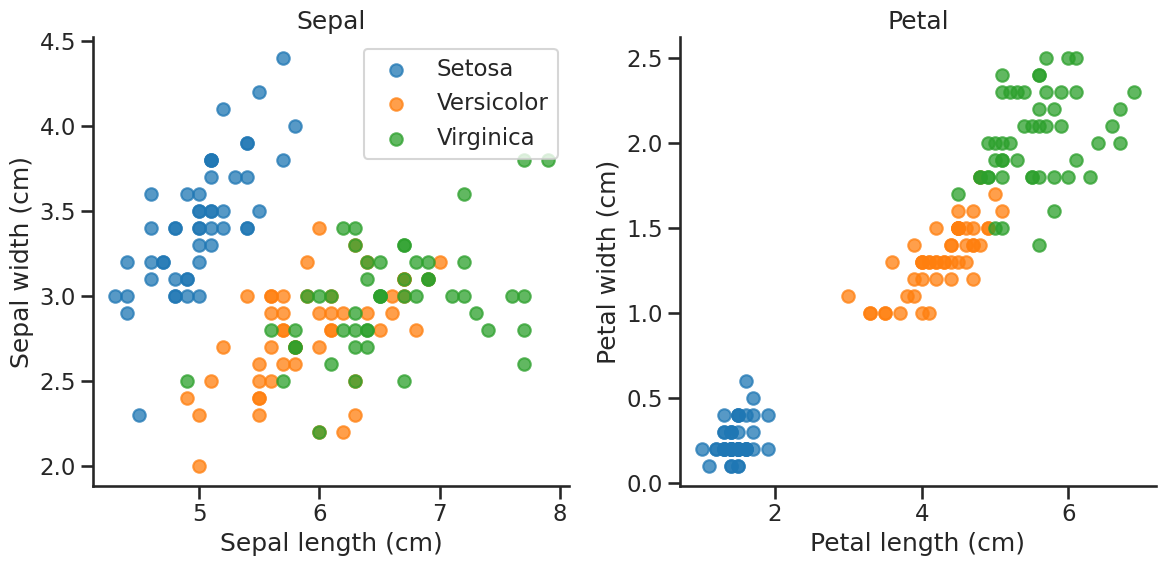

In [ ]:
# make figure
fig, axs = plt.subplots(1,2,figsize=(12,6), dpi=100)
# iterate iris types
for i, iris_type in enumerate(data['target_names']):
    # idx iris type
    idx = data['target']==i
    # plot sepal length / width
    axs[0].scatter(data['data'][idx,0], data['data'][idx,1],
                   color='C{}'.format(i),
                   alpha=0.75,
                   label=iris_type.capitalize())
    # plot petal length / width
    axs[1].scatter(data['data'][idx,2], data['data'][idx,3],
                   color='C{}'.format(i),
                   alpha=0.75,
                   label=iris_type.capitalize())
# add labels
axs[0].set_title('Sepal')
axs[0].set_xlabel(data['feature_names'][0].capitalize())
axs[0].set_ylabel(data['feature_names'][1].capitalize())
axs[1].set_title('Petal')
axs[1].set_xlabel(data['feature_names'][2].capitalize())
axs[1].set_ylabel(data['feature_names'][3].capitalize())
axs[0].legend(loc='upper right')
# save
for ax in axs:
    despine(ax=ax)
fig.tight_layout()
fig.savefig('Figure-0-1_Iris-Data.png', dpi=600)

# 2. Distinguishing setosa and versicolor irises by petal length and witdh:

For simplicity, we will only focus on setosa and versicolor irises and try to distinguish them by their petal width and length.

To do this, we will first subset our data to the classes 0 and 1 (setosa and versicolor) as well as the feature columns 2 and 3 (petal length and width):

In [ ]:
idx = np.isin(data['target'], (0, 1)) # get rows where target is either 0 or 1
X = data['data'][idx,2:4] # subset the data
y = data['target'][idx] # subset the labels
feature_names = data['feature_names'][2:4]

Our data subset now contains 100 instances (50 for each of the two iris types) and 2 features per instance:

In [ ]:
X.shape

(100, 2)

Looking at the data, distinguishing the two iris types should be easy (as we could simply draw a line between the yellow and blue dots):

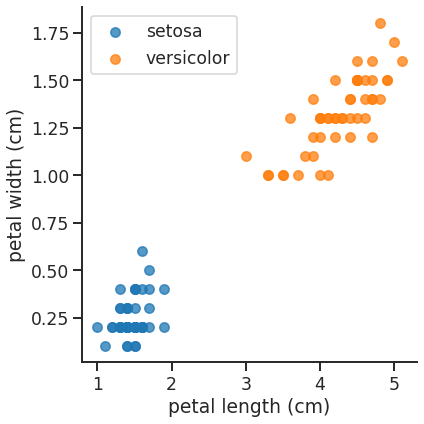

In [ ]:
# setup figure
fig, ax = plt.subplots(1, 1, figsize=(6,6), dpi=75)
# iterate the two target iris types
for cl in np.unique(y):
    # plot
    ax.scatter(x=X[y==cl,0],
               y=X[y==cl,1],
               color='C{}'.format(cl),
               label=data['target_names'][cl],
               alpha=0.75)
# add labels
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.legend()
despine(ax=ax)
fig.tight_layout()
# save figure
fig.savefig('Figure-0-2_Setosa-Versicolor-Petal.png', dpi=600)

But how can we learn this decision boundary (separating setosa and versicolor irises) with a classifier?

# 3. The Perceptron

In the following, we will use the [Perceptron algorithm](https://en.wikipedia.org/wiki/Perceptron) to learn a decision boundary separating the two iris types.

## 3.1 Inspired by biological neurons:

The Perceptron algorithm is loosely inspired by biological neurons.

A biological neuron receives signals of variable magnitude through its dendrites. These input signals are then accumulated in the cell body; If the accumulated signal exceeds a certain threshold, the neuron outputs a signal through its axon:

In [ ]:
Image(url='https://raw.githubusercontent.com/athms/deep-learning-basics/refs/heads/main/materials/images/free-use/Perceptron_neuron.png')

*source: https://sebastianraschka.com/Articles/2015_singlelayer_neurons.html*

## 3.2 Implementation

The Perceptron algorithm implements these basic biological processing steps as follows:

1. It receives an input signal for each feature $x_i$ of a data instance (in our example, the length and width of the petal).


2. These input signals are then scaled through a set of weights $w$ (one for each feature $x_i$ of the input) and summed (mimicking the "cell body" of the neuron; note that we here also add a constant $b$ to the sum (*the bias*)): $\sum_i w_ix_i + b$


3. Lastly, the weighted sum is scaled through an activation function $\phi$, representing the output of the perceptron.

In [ ]:
Image(url='https://raw.githubusercontent.com/athms/deep-learning-basics/refs/heads/main/materials/images/free-use/Perceptron.png' ,width=800, height=400)

### The activation function $\phi$:

The classical Percpetron algorithm uses a step activation function which outputs a value of 1 if the weighted sum is bigger than 0 and -1 otherwise.

Here, we will be using the sigmoid activation function instead. The sigmoid scales its input to a value between 0 and 1. It can thereby be used to estimate a probability that each data instance belongs to class 1 (i.e., versicolor irises).

In [ ]:
def step(x):
    """step function:
    outputs 1 if x > 0
    and -1 otherwise"""
    xout = np.ones_like(x)
    xout[x<0] = -1
    return xout

def sigmoid(x):
    """sigmoid function"""
    return 1.0/(1.0 + np.exp(-x))

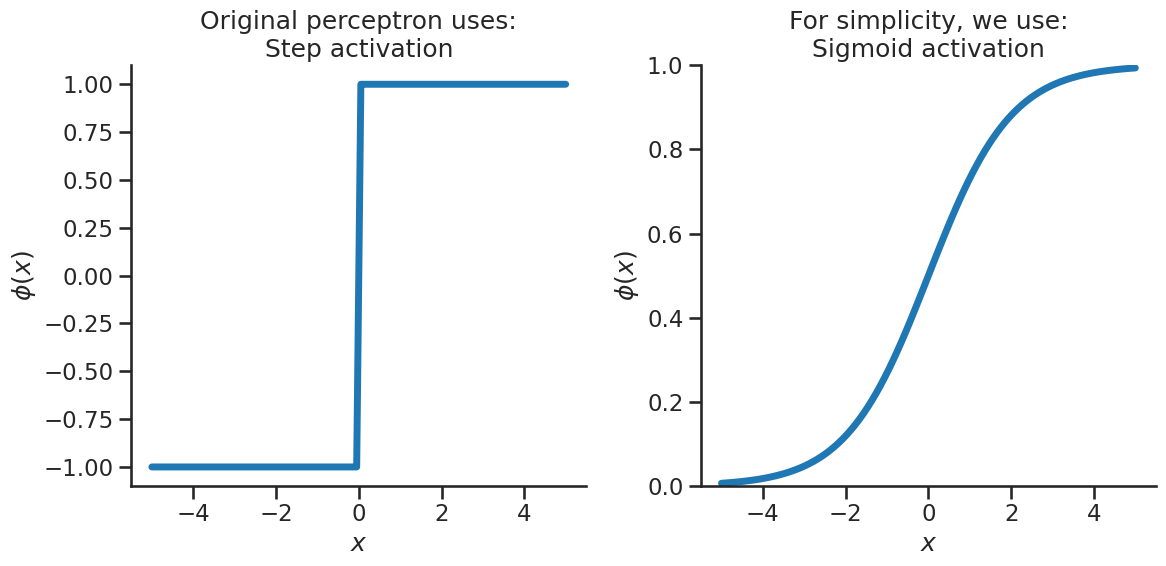

In [ ]:
# setup figure
fig, axs = plt.subplots(1,2,figsize=(12,6), dpi=100)

# set input range
x = np.linspace(-5,5,100)

# Step activation
axs[0].set_title('Original perceptron uses:\nStep activation')
axs[0].plot(x, step(x), lw=5)
axs[0].set_ylabel(r'$\phi(x)$')
axs[0].set_xlabel(r'$x$')

# Sigmoid activation
axs[1].set_title('For simplicity, we use:\nSigmoid activation')
axs[1].plot(x, sigmoid(x), lw=5)
axs[1].set_ylabel(r'$\phi(x)$')
axs[1].set_xlabel(r'$x$')
axs[1].set_ylim(0, 1)

# despine
for ax in axs:
    despine(ax=ax)
fig.tight_layout()

# save
fig.savefig('Figure-0-3_Perceptron-Activation.png', dpi=600)

# 4. The loss function

We have decided on an architecture for our classifcation algorithm.

How do we now determine the set of weights $w$ that allow us to best distinguish between the two iris types?

To do this, we need to define a loss function. Conceptually, a loss function indicates the current error of the model, given a set of parameter weights. For our perceptron algorithm, we can use the binary [cross-entropy loss](https://ml-cheatsheet.readthedocs.io/en/latest/loss_functions.html):

$L = -(y \times log(p) + (1-y) \times log(1-p))$

The cross-entropy loss consists of two main components: one applies if $y = 1$ and the other if $y = 0$.

Let's look at these two parts of the loss in more detail:

/tmp/ipython-input-2846757666.py:8: RuntimeWarning: divide by zero encountered in log
  axs[0].plot(p, -np.log(p), lw=5)
/tmp/ipython-input-2846757666.py:15: RuntimeWarning: divide by zero encountered in log
  axs[1].plot(p, -np.log(1-p), lw=5, color='red')


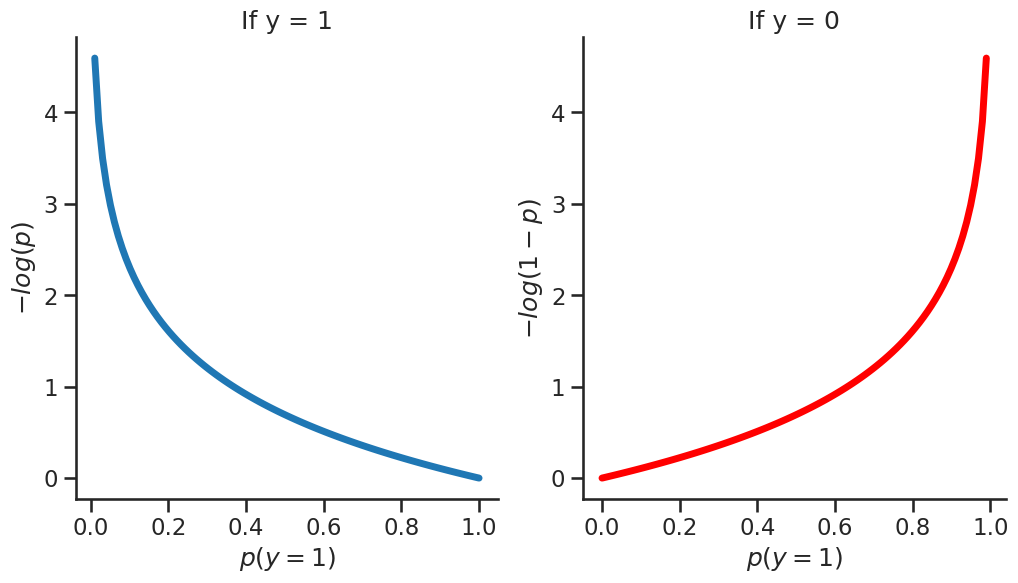

In [ ]:
# setup figure
fig, axs = plt.subplots(1,2,figsize=(12,6),dpi=100)

# predicted probability that y = 1
p = np.linspace(0,1,100)

# plot loss if y = 1
axs[0].plot(p, -np.log(p), lw=5)
axs[0].set_title('If y = 1')
axs[0].set_ylabel(r'$-log(p)$')
axs[0].set_xlabel(r'$p(y=1)$')
(despine(ax=axs[0]))

# plot loss if y = 0
axs[1].plot(p, -np.log(1-p), lw=5, color='red')
axs[1].set_title('If y = 0')
axs[1].set_ylabel(r'$-log(1-p)$')
axs[1].set_xlabel(r'$p(y=1)$')
(despine(ax=axs[1]))

# save
fig.savefig('Figure-0-4_Cross-Entropy-Loss.png', dpi=600)

We can see that the first part of the loss ($-log(p)$; in blue) is minimal when the prediction $p(y=1)$ (or $\phi(x)$) of our model is close to $1$. Similarly, the second part of the loss ($-log(1-p)$; in red) is minimal when the prediction $p(y=1)$ of our model is close to $0$.

Hence, the cross-entropy loss is minimal if our predicted probabilities are as close as possible to the actual target classes (0 and 1). It will thus be our goal to find the set of weights $w$ that overall minimizes the cross-entropy loss.

For our binary classification problem we can actually take a look at how the loss function changes as a function of the two weights of our perceptron (one for each feature of the data (petal width and length) see below).

Note that we fix the bias parameter $b$ for illustrative purposes in this analysis.

In [ ]:
# we define the loss as a Python class:
class cross_entropy_loss:
    def __init__(self):
        self.name = 'cross-entropy'

    def loss(self, y, y_pred, zerotol=1e-10):
        """the cross-entropy loss for each
        data instance

        Args:
            y (array): labels for each instance (0 or 1)
            y_pred (array): predicted probabilty that
                each instance belongs to class 1
        """
        loss = -(y * np.log(y_pred + zerotol) + (1 - y) * np.log(1 - y_pred + zerotol))
        return loss

    def derivative_loss(self, y, y_pred):
        """the derivative of the cross-entropy loss w.r.t.
        to sigmoid activation function (we will get to
        this later)

        Args:
            y (array): labels for each instance (0 or 1)
            y_pred (array): predicted probabilty that
                each instance belongs to class 1
        """
        return y_pred - y

In [ ]:
# create an instance of our loss function
xeLoss = cross_entropy_loss()

b = -19 # lets set the bias to -19, so that we can plot the two dimensional loss surface
# (trust me, this is a good value here ^^)

# define the grid of w-values for which we want to compute the loss:
w1grid = np.linspace(-10, 30, 100)
w2grid = np.linspace(-10, 30, 100)
ww1, ww2 = np.meshgrid(w1grid, w2grid) # grid indices for w1 and w2 values

# compute the loss for each point on the grid
zz = np.zeros(ww1.shape)
for i in range(zz.shape[0]):
    for j in range(zz.shape[1]):
        w = np.array([ww1[i,j], ww2[i,j]])
        y_pred = sigmoid(X.dot(w)+b)
        # we average the loss over all data instances
        zz[i, j] += np.mean(xeLoss.loss(y, y_pred))

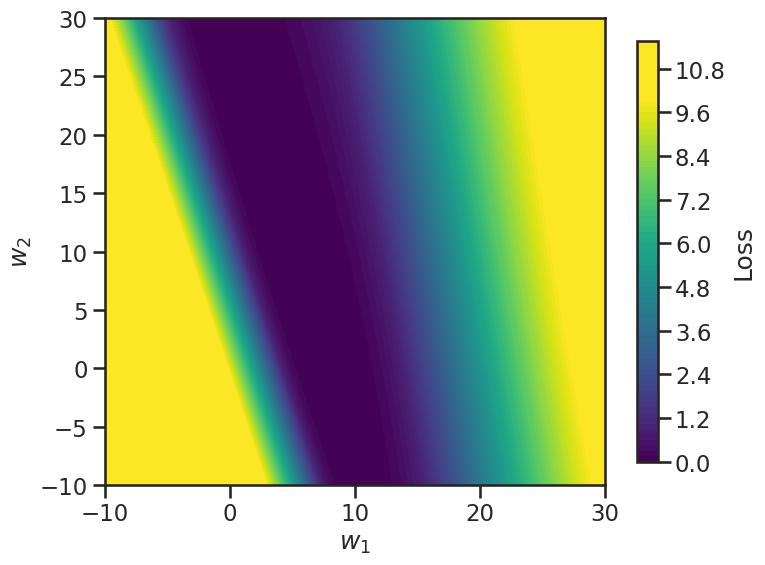

In [ ]:
# setup figure
fig, ax = plt.subplots(1, 1, figsize=(8,6), dpi=100)
# plot contour
cs = ax.contourf(ww1, ww2, zz, 100, vmax=10, cmap=cm.viridis)
cbar = fig.colorbar(cs, ax=ax, shrink=0.9)
# label axes
cbar.set_label('Loss')
ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$")
# save figure
fig.tight_layout()
fig.savefig('Figure-0-2_Perceptron-Loss.png', dpi=600)

To get a better feeling for the slope (or steepness) of the loss surface, let's also look at this in 3D:

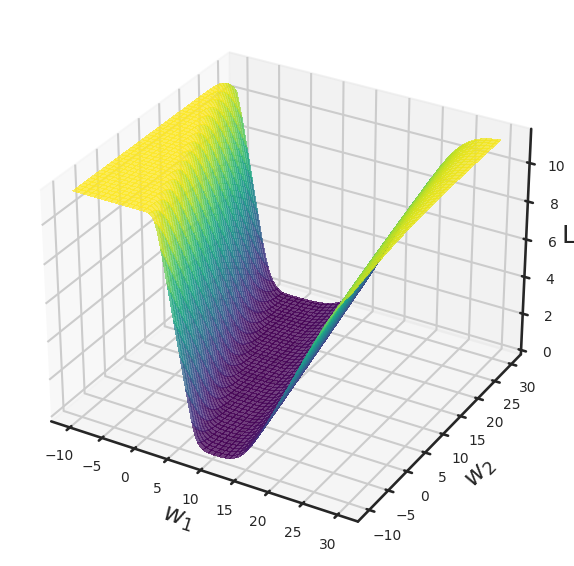

In [ ]:
# import 3D functionality
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
# setup figure
fig = plt.figure(figsize=(8,6), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# plot surface
ax.plot_surface(ww1, ww2, zz, alpha=0.75, cmap=cm.viridis,
                linewidth=0, antialiased=False, zorder=-99)
# add labels
ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$")
ax.set_zlabel('Loss', labelpad=7)
ax.tick_params(labelsize=10) # increase labelsize
fig.tight_layout()
# save
fig.savefig('Figure-0-3_Perceptron-Loss-3D.png', dpi=600)

Ok! This is a pretty steep descent with a very clear valley; Finding a minimum should be easy!

But how do we find the minimum of our loss surface?

# 5. (Stochastic) gradient descent

[Gradient descent](https://en.wikipedia.org/wiki/Gradient_descent) is one of the most central techniques of modern machine learning. Its goal is to find a (local) minimum of a loss function, given an input dataset.

We have already seen that our loss function changes with the values of our two Perceptron weights $w$.

To find the weights that minimize the loss function, gradient descent procedes as follows:

1. First, it initializes the weights randomly (here, between -1 and 1).


2. Subsequently, it computes the partial derivative of the loss function with respect to the current weights (we denote this partial dericative by: $\frac{dL}{dw}$). This partial derivative indicates how much the loss function changes at its current value w.r.t. a change in $w$:
    - A negative derivative indicates that the loss decreases with an increase in $w$
    - A positive derivative indicates that the loss increases with an increasing $w$.


3. Thus, to move closer to the minimum of the loss, gradient descent simply subtracts the partial derivative from the current set of weights $w = w - \alpha \times \frac{dL}{dw}$. Note that we also scale the derivative by $\alpha$ (*the learning rate*), allowing us to adjust the overall size of the step that we take at each iteration.


4. The gradient descent algorithm then procedes to iteratively repeat steps 2 and 3 until it reaches a (local) minimum of the loss function. Typically, we know that we have reached a (local) minimum when the partial derivatives (and thereby the weights) do not change much anymore (as the partial derivatives should be close to 0 at a minimum of the loss function).

Note that the loss function is typically more complex for high-dimensional parameter spaces than indicated by our illustration below. In these high-dimensional settings, there often exist many different local minima of the loss function (each representing a distinct set of paramater weights) which result in a very similar overall loss value. Knowing whether your algorithm has converged on any of these local mimima or the overall global minimum (indicating the overall lowest loss value) is difficult. Therefore it is often advised to repeatedly fit your algorithm to your dataset with different random initializations and to see how this changes the performance of your classifier. For a more detailed review on this, see for example this [blog post](https://blog.paperspace.com/intro-to-optimization-in-deep-learning-gradient-descent/).  

In [ ]:
Image(url='https://raw.githubusercontent.com/athms/deep-learning-basics/refs/heads/main/materials/images/free-use/Gradient-Descent.png',width=800,height=500)

# 6. Our Perceptron implementation

Now that we have learned about the Perceptron and gradient descent, let's put it all together:

In [ ]:
# here we construct a Python class implementing the
# perceptron and gradient descent algorithm:

class Perceptron:

    def __init__(self, n_in, activation=sigmoid, loss=cross_entropy_loss, b=None):
        """A simple Perceptron implementation;
        This implementation also contains the
        gradient descent algorithm (see the
        gradient_descent_step and train
        functions).

        Args:
            n_in (int): number of input features for each instance
            activation (function): activation function of the Perceptron;
                only takes x as input
            loss (function): loss function that we use;
                (this should be the cross_entropy
                loss for a sigmoid activation)
            b (float): bias term; if a value is specified, the
                bias term is fixed at this value. if not,
                the bias will be estimated during training.
        """
        self.n_in = n_in
        self.w = np.random.uniform(-1,1,n_in)
        if b is None:
            self.b = np.random.uniform(-1,1,1)
            self.fit_b = True
        else:
            self.b = b
            self.fit_b = False
        self.activation = activation
        self.loss = loss().loss
        self.derivative_loss = loss().derivative_loss

    def predict(self, x):
        """Predict probability that each
        instance of x (with shape n_instances x n_features)
        belongs to class 1

        Args:
            x (ndarray): input data (n_instances x n_features)

        Returns:
            predicted probability for each instance
        """
        self.Z = np.dot(x, self.w) + self.b
        self.A = self.activation(self.Z)
        return self.A

    def gradient_descent_step(self, x, y, learning_rate):
        """A single gradient descent step.

        Args:
            x (ndarray): input data (n_instances x n_features)
            y (array): label of each instance (0 or 1)
            learning_rate (float): learning rate of the
                gradient descent algorithm
        """
        # compute derivative of loss wrt Z
        dZ = self.derivative_loss(y, self.predict(x))
        dW = np.dot(dZ, x)
        # subtract average derivative from weights
        self.w -= learning_rate * 1.0/dW.shape[0] * dW
        if self.fit_b:
            self.b -= learning_rate * (1.0/x.shape[0] * np.sum(dZ))

    def train(self, x, y, batch_size=8, learning_rate=1, n_steps=100):
        """Iteratively train the Perceptron.
        At each iteration, the algorithm will draw
        a random sample from x and perform a weight
        update with the partial derivatives that
        are computed from this sample.

        Args:
            x (ndarray): input data (n_instances x n_features)
            y (array): label of each instance (0 or 1)
            learning_rate (float): learning rate of the
                gradient descent algorithm
            n_steps (int): number of gradient descent
                iterations to perform during training
        """
        self.training_w = np.zeros((n_steps, self.n_in+1))
        self.training_loss = np.zeros(n_steps)
        for s in tqdm(range(n_steps)):
            # draw a random batch
            batch_idx = np.random.choice(x.shape[0], batch_size, replace=False)
            # compute and store mean loss
            self.training_loss[s] = np.mean(self.loss(y[batch_idx], self.predict(X[batch_idx])))
            # store current weights
            self.training_w[s,:self.n_in] = self.w
            self.training_w[s,-1] = self.b
            # perform a gradient descent step
            self.gradient_descent_step(X[batch_idx], y[batch_idx], learning_rate)

# 7. Applying our implementation

Can our Perceptron implementation actually learn a decision boundary that allows us to accurately distinguish between setosa and versicolor irises, given their petal length and width?

To give better insight into the training process, we will perform each gradient descent step manually, by the use of the `predict`, `loss`, and `gradient_descent_step` functions of our `Perceptron` implementation (This process is otherwise also wrapped in the `train` function).

**Note** that we do not use the full dataset to update our weights at each iteration, but instead draw a random sample at each iteration. We use each random sample to compute an estimate of our partial derivatives. This procedure is called [*stochastic* gradient descent](https://en.wikipedia.org/wiki/Stochastic_gradient_descent) and is common in the machine learning literature, especially for large datasets (for which it would be otherwise too costly to compute the partial derivatives for the entire dataset at each iteration).

In [ ]:
# set a random seed
np.random.seed(4123)

# create instance of our Perceptron
perceptron = Perceptron(n_in=2, b=-19) # n_in: number of input features that our Perceptron expects
# we set our bias value to -19, as previously discussed

# gradient descent settings
n_steps = 35000 # number of gradient descent iterations (or steps)
batch_size = 32 # number of random samples that we draw at each iteration

# create containers to store the loss and weight values at each step
training_loss = np.zeros(n_steps)
training_w = np.zeros((n_steps+1,2))
training_w[0] = np.array(perceptron.w) # store randomly initialized weights

# manually iterate the gradient descent steps
for s in tqdm(range(n_steps)):
    # lets draw a random batch
    batch_idx = np.random.choice(X.shape[0], batch_size, replace=False)
    # and compute the loss for our random sample
    training_loss[s] = np.mean(perceptron.loss(y[batch_idx], perceptron.predict(X[batch_idx])))
    # we also update the weights in a gradient descent step
    # (for details, see the perceptron implementation above):
    perceptron.gradient_descent_step(x=X[batch_idx], y=y[batch_idx], learning_rate=0.5)
    # and store the updated weights
    training_w[s+1] = np.array(perceptron.w)

100%|██████████| 35000/35000 [00:02<00:00, 11897.75it/s]


Ok, lets take a look at the results:

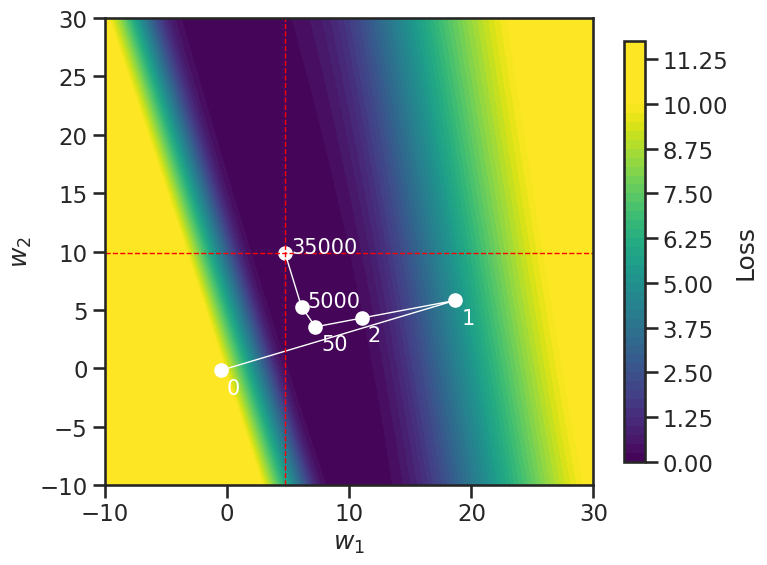

In [ ]:
# setup figure
fig, ax = plt.subplots(1, 1, figsize=(8,6))
# plot contour
cs = ax.contourf(ww1, ww2, zz, 50, vmax=10, cmap=cm.viridis)
cbar = fig.colorbar(cs, ax=ax, shrink=0.9)
# plot gradient descent trajectory
steps = np.array([0,1,2,50,5000,35000])
ax.scatter(training_w[steps,0], training_w[steps,1], color='white')
ax.plot(training_w[steps,0], training_w[steps,1], color='white', lw=1)
for s in steps:
    if s < 100:
        ax.text(training_w[s,0]+0.5, training_w[s,1]-2, s, color='white', fontsize=15)
    else:
        ax.text(training_w[s,0]+0.5, training_w[s,1], s, color='white', fontsize=15)
# mark final weight values
ax.axvline(training_w[s,0], color='red', lw=1, ls='--')
ax.axhline(training_w[s,1], color='red', lw=1, ls='--')
# label axes
cbar.set_label('Loss')
ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$")
# save figure
fig.tight_layout()
fig.savefig('Figure-0-4_Perceptron-Loss-Gradinet-Descent-Path.png', dpi=600)

Interesting; It looks like we choose a learning rate that was a bit too large: The first gradient descent step took us all the way across the valley!

Luckily, we then from there traveled safely down to a minimum. Our final weight values are marked by the red cross.

Also note how the individual steps are getting smaller towards the end (traveling the distance between the last two points took 30,000 weight updates).

# 8. The learned decision function

Now that we have a parameter estimate (as marked with the red cross in the plot above), we can test whether our trained Perceptron accurately distinguishes between setosa and versicolor irises!

To do this, we will plot its decision boundary:

In [ ]:
# define a grid of x1 and x2 values for
# which we want to predict the probability
# that each data point belongs to class 1
x1grid = np.linspace(0, 6, 50)
x2grid = np.linspace(0, 2, 50)
# create all of the rows and columns of the grid
xx1, xx2 = np.meshgrid(x1grid, x2grid)
# flatten each grid to a vector
x1, x2 = xx1.flatten(), xx2.flatten()
x1, x2 = x1.reshape((-1, 1)), x2.reshape((-1, 1))
# horizontal stack vectors to create x1, x2 input for the model
grid = np.hstack((x1, x2))

In [ ]:
# predict probability that each point
# of the grid belongs to class 1
zz = perceptron.predict(grid).reshape(xx1.shape)

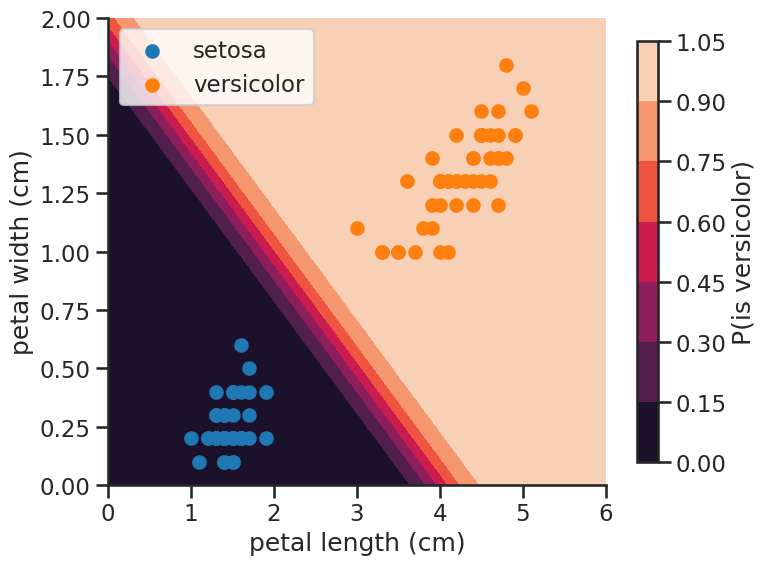

In [ ]:
# setup figure
fig, ax = plt.subplots(1, 1, figsize=(8,6))
# plot predicted probabilities
cs = ax.contourf(xx1, xx2, zz)
cbar = fig.colorbar(cs, ax=ax, shrink=0.9)
cbar.set_label('P(is {})'.format(data['target_names'][1]))
# add scatter markers for instances of each iris type
for cl in np.unique(y):
    idx = y==cl
    ax.scatter(x=X[idx,0],
               y=X[idx,1],
               color='C{}'.format(cl),
               label=data['target_names'][cl],
               alpha=1)
# add labels
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.legend()
despine(ax=ax)
# save figure
fig.tight_layout()
fig.savefig('Figure-0-5_Perceptron-Decision-Function.png', dpi=600)

Yay! Our perceptron accurately distinguishes the two iris types.

Importantly, the decision boundary of the Perceptron represents a [hyperplane](https://en.wikipedia.org/wiki/Hyperplane) (a subspace whose dimension is one less than that of the input data; for two-dimensional data, the decision boundary thus represents a straight line).

# 9. Your Exercise

To give you a more intuitive understanding of the interplay between the number of iterations, the batch size, and the learning rate of the gradient descent algorithm, play around with them in the code below.

The code will output a figure of the loss surface, your gradient descent steps, and final loss value.

**1. What would be a good learning rate and batch size for this problem?**

**2. What is the smallest loss that you can achieve?**

In [ ]:
# Clone the repository
!git clone --depth 1 --filter=blob:none --sparse https://github.com/athms/deep-learning-basics.git
%cd deep-learning-basics
!git sparse-checkout set helpers
import sys
# Add the helpers directory to the Python path
sys.path.append('/content/deep-learning-basics/helpers')

In [ ]:
# we import a small helper function for plotting for this exercise:
from helpers.plotting import plot_gradient_descent_path

# set random seed
np.random.seed(4123)



# ---------------
# Your values go here:

n_steps = 4000 # number of gradient descent steps
batch_size = 100 # number of random samples drawn at each iteration (needs to be < 101)
learning_rate = 0.1 # try values between 0.001 and 10

# ---------------



# initialize Perceptron
perceptron = Perceptron(n_in=2) # this time we do not fixate the bias, but learn it also!
# train perceptron
perceptron.train(x=X, y=y,
                 n_steps=n_steps+1,
                 batch_size=batch_size,
                 learning_rate=learning_rate)
print('Your final loss is: {}'.format(perceptron.training_loss[-1]))


# plot gradient descent path
fig, ax = plot_gradient_descent_path(perceptron, X, y)